# PANGENOME ANALYSIS

In [61]:
.libPaths("~/R/lib")

library(ape)
library(pheatmap)
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(tibble)
library(purrr)
library(ggrepel)
library(pheatmap)
library(tidyr)
library(ggtree)
library(vegan) 
library(rlang)
library(ggtreeExtra)
library(ggnewscale)
library(patchwork)
library(cowplot)
library(RColorBrewer)

### TANZANIA - our data

In [2]:
# FILES

pangenome_dir <- "../../results_for_analysis/pangenome/tanzania"

# metadata with correct st and passed samples
meta <- read_tsv("../../results_for_analysis/metadata/metadata_tidy_tanzania.tsv")

# read roary files
gene_pa <- read_tsv(
  file.path(pangenome_dir, "gene_presence_absence.Rtab"),
  show_col_types = FALSE
)

treefile <- read.tree(file.path(pangenome_dir, "core_genome_tree.nwk"))


Rows: 53 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): sample, date, sample_type, host, region, animal_contact, species
dbl (1): ST

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


total_gene_families,core_genes,accessory_genes,unique_genes
<int>,<int>,<int>,<int>
5325,1863,3462,1175


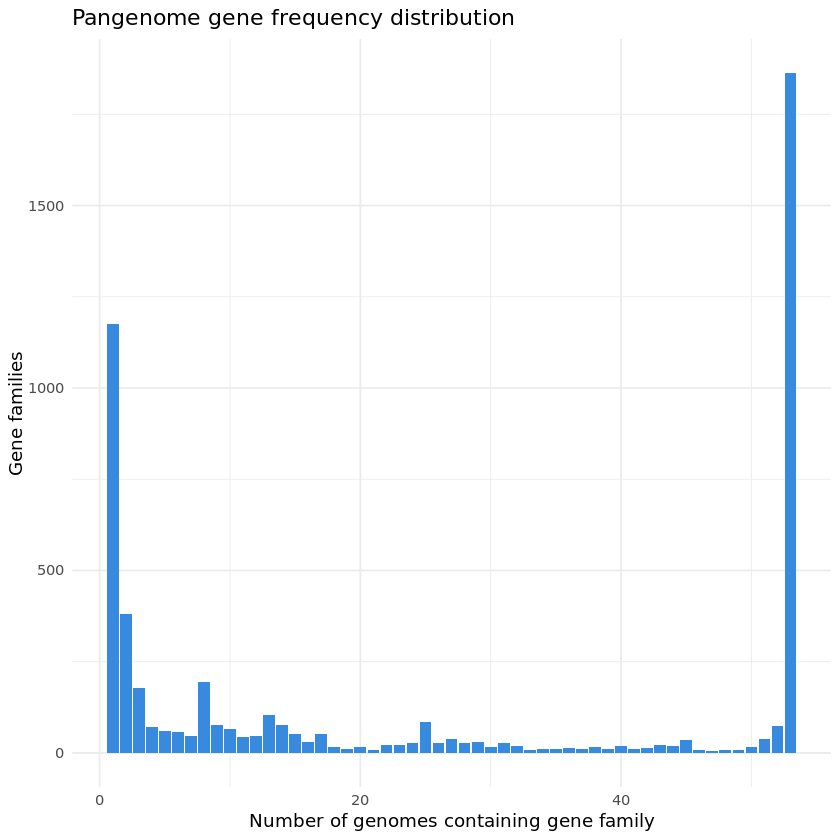

In [3]:

# first column is gene family name; remaining columns are isolates
gene_id <- gene_pa[[1]]
pa_mat <- gene_pa[, -1]
pa_mat <- as.matrix(pa_mat)
rownames(pa_mat) <- gene_id

# basic pangenome summary
n_genomes <- ncol(pa_mat)
genes_per_family <- rowSums(pa_mat > 0)

pangenome_summary <- tibble(
  total_gene_families = nrow(pa_mat),
  core_genes = sum(genes_per_family == n_genomes),
  accessory_genes = sum(genes_per_family < n_genomes),
  unique_genes = sum(genes_per_family == 1)
)

pangenome_summary

top_genes <- rownames(pa_mat)[order(genes_per_family, decreasing = TRUE)][1:min(100, nrow(pa_mat))]
# gene frequency plot
gene_freq_df <- tibble(
  genomes_with_gene = genes_per_family
) |>
  count(genomes_with_gene)

ggplot(gene_freq_df, aes(x = genomes_with_gene, y = n)) +
  geom_col(fill = "#378ADD") +
  theme_minimal() +
  labs(
    x = "Number of genomes containing gene family",
    y = "Gene families",
    title = "Pangenome gene frequency distribution"
  )



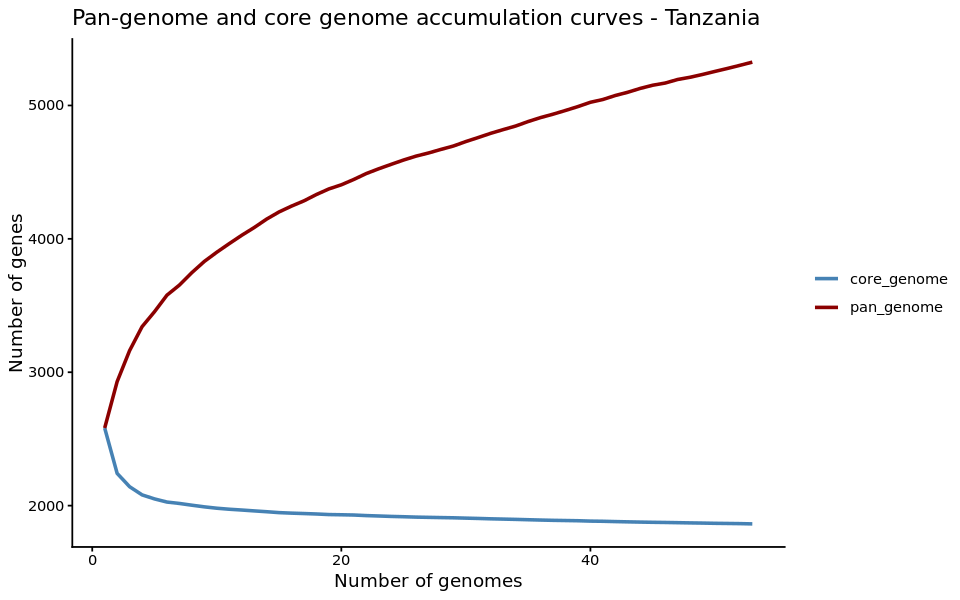

In [4]:
# pangenome accumulation curve
options(repr.plot.width = 8, repr.plot.height = 5)

set.seed(42)

pan_binary <- as.matrix(pa_mat > 0)   # genes x genomes
n_perms <- 100

pan_sum  <- numeric(ncol(pan_binary))
core_sum <- numeric(ncol(pan_binary))

for (i in seq_len(n_perms)) {
  sample_order <- sample(ncol(pan_binary))
  
  for (j in seq_along(sample_order)) {
    subset <- pan_binary[, sample_order[1:j], drop = FALSE]
    
    pan_sum[j]  <- pan_sum[j]  + sum(rowSums(subset) >= 1)
    core_sum[j] <- core_sum[j] + sum(rowSums(subset) == j)
  }
}

pan_curve  <- pan_sum / n_perms
core_curve <- core_sum / n_perms

curve_df <- tibble(
  n_genomes   = seq_len(ncol(pan_binary)),
  pan_genome  = pan_curve,
  core_genome = core_curve
) |>
  pivot_longer(-n_genomes, names_to = "type", values_to = "genes")

ggplot(curve_df, aes(x = n_genomes, y = genes, color = type)) +
  geom_line(linewidth = 1) +
  scale_color_manual(values = c(
    pan_genome = "darkred",
    core_genome = "steelblue"
  )) +
  labs(
    x = "Number of genomes",
    y = "Number of genes",
    title = "Pan-genome and core genome accumulation curves - Tanzania",
    color = NULL
  ) +
  theme_classic()

options(repr.plot.width = 12, repr.plot.height = 5)

#### Tree view

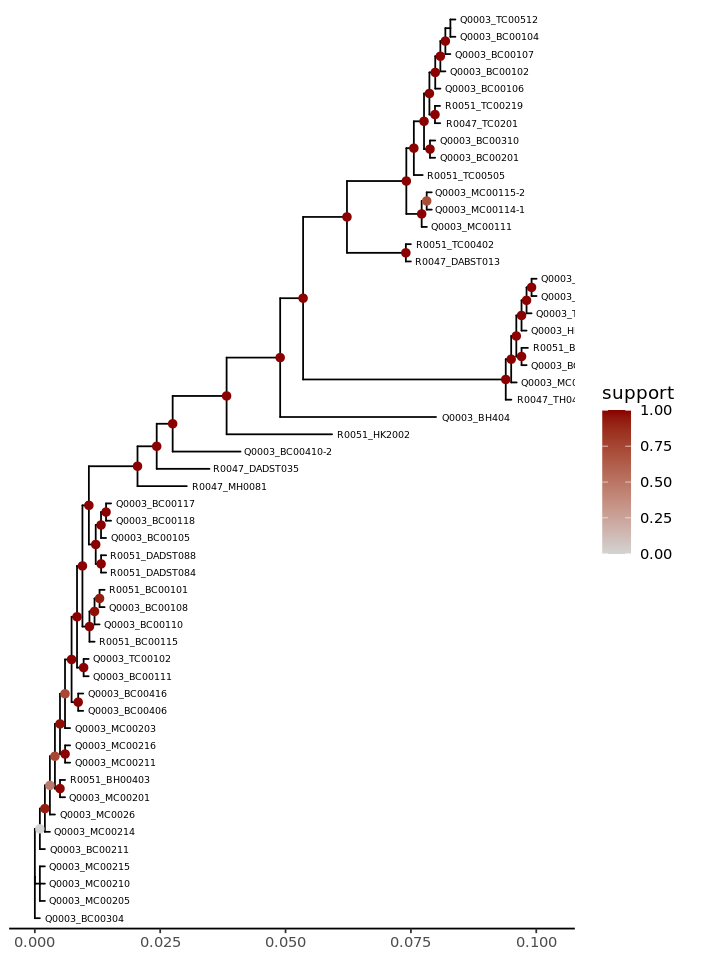

In [23]:
options(repr.plot.width = 6, repr.plot.height = 8)

treefile <- read.tree(file.path(pangenome_dir, "core_genome_tree.nwk"))

tree_mod <- treefile
tree_mod$edge.length <- tree_mod$edge.length * 3 + 0.001

# plot: show node support >= 0.7 as percent and color nodes by support
p_base_tree <- ggtree(tree_mod)

p_tree <- p_base_tree +
  geom_point2(aes(subset = !is.na(suppressWarnings(as.numeric(label))),
                  color = suppressWarnings(as.numeric(label))),
              size = 2) +
  scale_color_gradient(low = "lightgrey", high = "darkred", na.value = "grey80", name = "support") +
  geom_tiplab(aes(label = label), angle = 0, hjust = 0.1, size = 2, offset = 0.002) +
  theme_tree2() + theme(plot.margin = margin(5.5, 25, 5.5, 5.5))

p_tree

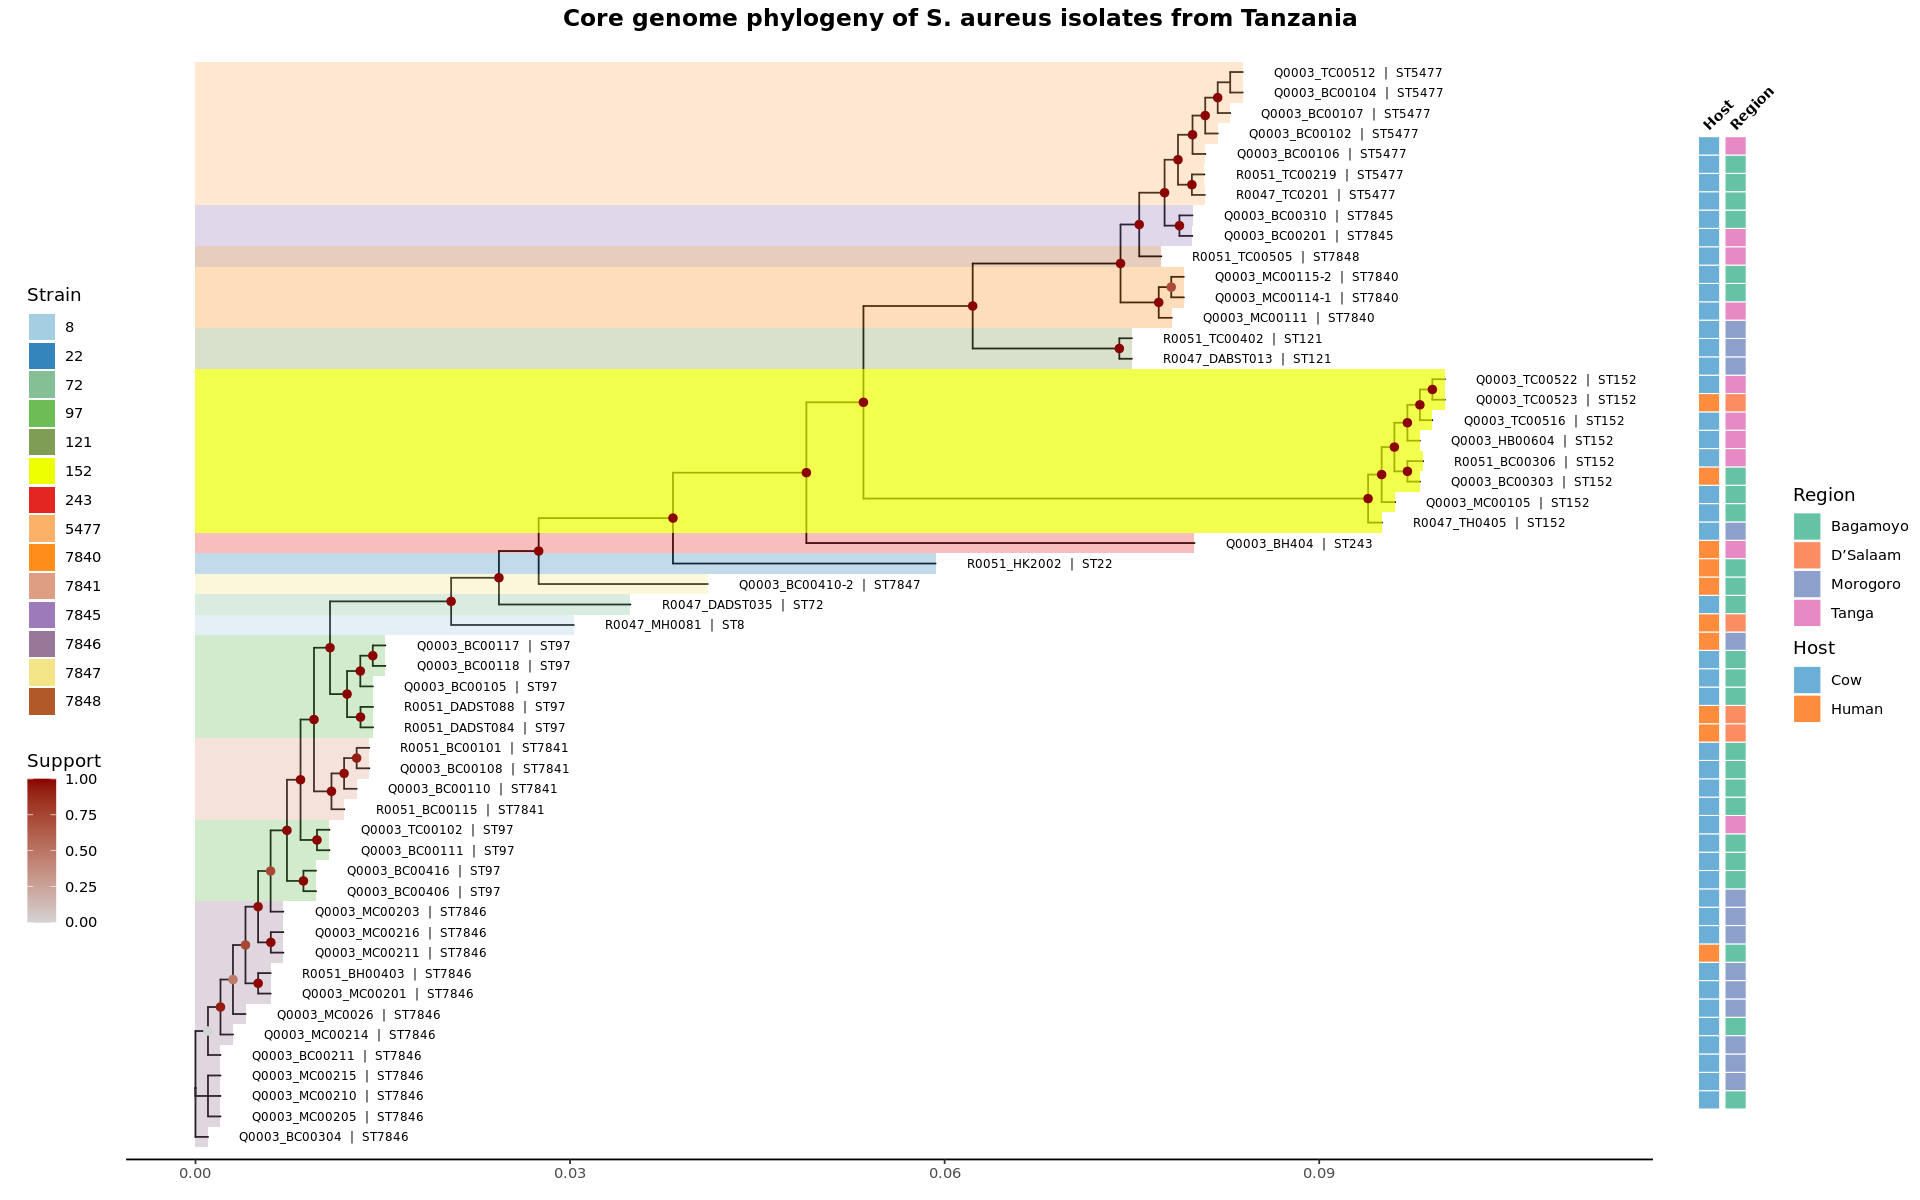

In [14]:
options(repr.plot.width = 16, repr.plot.height = 10)
library(patchwork)

st_colours <- setNames(
  colorRampPalette(RColorBrewer::brewer.pal(12, "Paired"))(nlevels(meta$ST)),
  levels(meta$ST)
)
st_colours["152"] <- "#eeff01"

host_colours   <- c("Cow" = "#6BAED6", "Human" = "#FD8D3C")
region_colours <- setNames(
  RColorBrewer::brewer.pal(max(3, nlevels(meta$region)), "Set2")[seq_len(nlevels(meta$region))],
  levels(meta$region)
)

# ── tree prep ─────────────────────────────────────────────────────────────────
tree_mod <- treefile
tree_mod$edge.length <- tree_mod$edge.length * 3 + 0.001

p_base <- ggtree(tree_mod) %<+% meta

tip_data <- p_base$data %>%
  filter(isTip) %>%
  left_join(meta, by = c("label" = "sample")) %>%
  arrange(y) %>%
  mutate(tip_label = paste0(label, "  |  ST", ST.y),
         st_alpha  = ifelse(ST.y == "152", 0.7, 0.3))

# ── build tree with labels, get x range ───────────────────────────────────────
p_base2 <- ggtree(tree_mod) %<+% tip_data
x_max <- max(tip_data$x) + 0.001

p_tree <- p_base2 +
  geom_rect(
    data = tip_data,
    aes(xmin = 0, xmax = x,
        ymin = y - 0.5, ymax = y + 0.5,
        fill = ST.y, alpha = st_alpha),
    inherit.aes = FALSE
  ) +
  scale_fill_manual(values = st_colours, name = "Strain") +
  scale_alpha_identity() +
  new_scale_color() +
  geom_point2(
    aes(subset = !is.na(suppressWarnings(as.numeric(label))),
        color  = suppressWarnings(as.numeric(label))),
    size = 2
  ) +
  scale_color_gradient(low = "lightgrey", high = "darkred",
                       na.value = "grey80", name = "Support") +
  geom_tiplab(aes(label = tip_label), size = 2.5, offset = 0.002) +
  xlim(0, x_max * 1.1) + 
  theme_tree2() +
  theme(plot.margin     = margin(5.5, 5, 5.5, 5.5),
        legend.position = "left")

# ── annotation plot ───────────────────────────────────────────────────────────
y_min <- min(tip_data$y) - 0.5
y_max <- max(tip_data$y) + 0.5

annot_data <- tip_data %>%
  select(label, y, host = host.y, region = region.y, ST = ST.y)

p_annot <- ggplot(annot_data) +
  geom_tile(aes(x = 1, y = y, fill = host),
            width = 0.8, color = "white", linewidth = 0.3) +
  scale_fill_manual(values = host_colours, name = "Host") +
  new_scale_fill() +
  geom_tile(aes(x = 2, y = y, fill = region),
            width = 0.8, color = "white", linewidth = 0.3) +
  scale_fill_manual(values = region_colours, name = "Region") +
  # angled column labels on top
  annotate("text", x = 1, y = y_max + 0.3, label = "Host",
           angle = 45, hjust = 0, vjust = 0, size = 3, fontface = "bold") +
  annotate("text", x = 2, y = y_max + 0.3, label = "Region",
           angle = 45, hjust = 0, vjust = 0, size = 3, fontface = "bold") +
  coord_cartesian(ylim = c(y_min, y_max + 2), clip = "off") +
  scale_x_continuous(breaks = NULL, expand = c(0.5, 0.5)) +
  theme_void() +
  theme(legend.position = "right",
        plot.margin     = margin(5.5, 5.5, 5.5, 0))

# ── combine ───────────────────────────────────────────────────────────────────
p_tree + p_annot +
  plot_layout(widths = c(5, 0.4)) +
  plot_annotation(
    title = "Core genome phylogeny of S. aureus isolates from Tanzania",
    theme = theme(plot.title = element_text(size = 14, face = "bold", hjust = 0.5))
  )

Accessory genes: 3462 


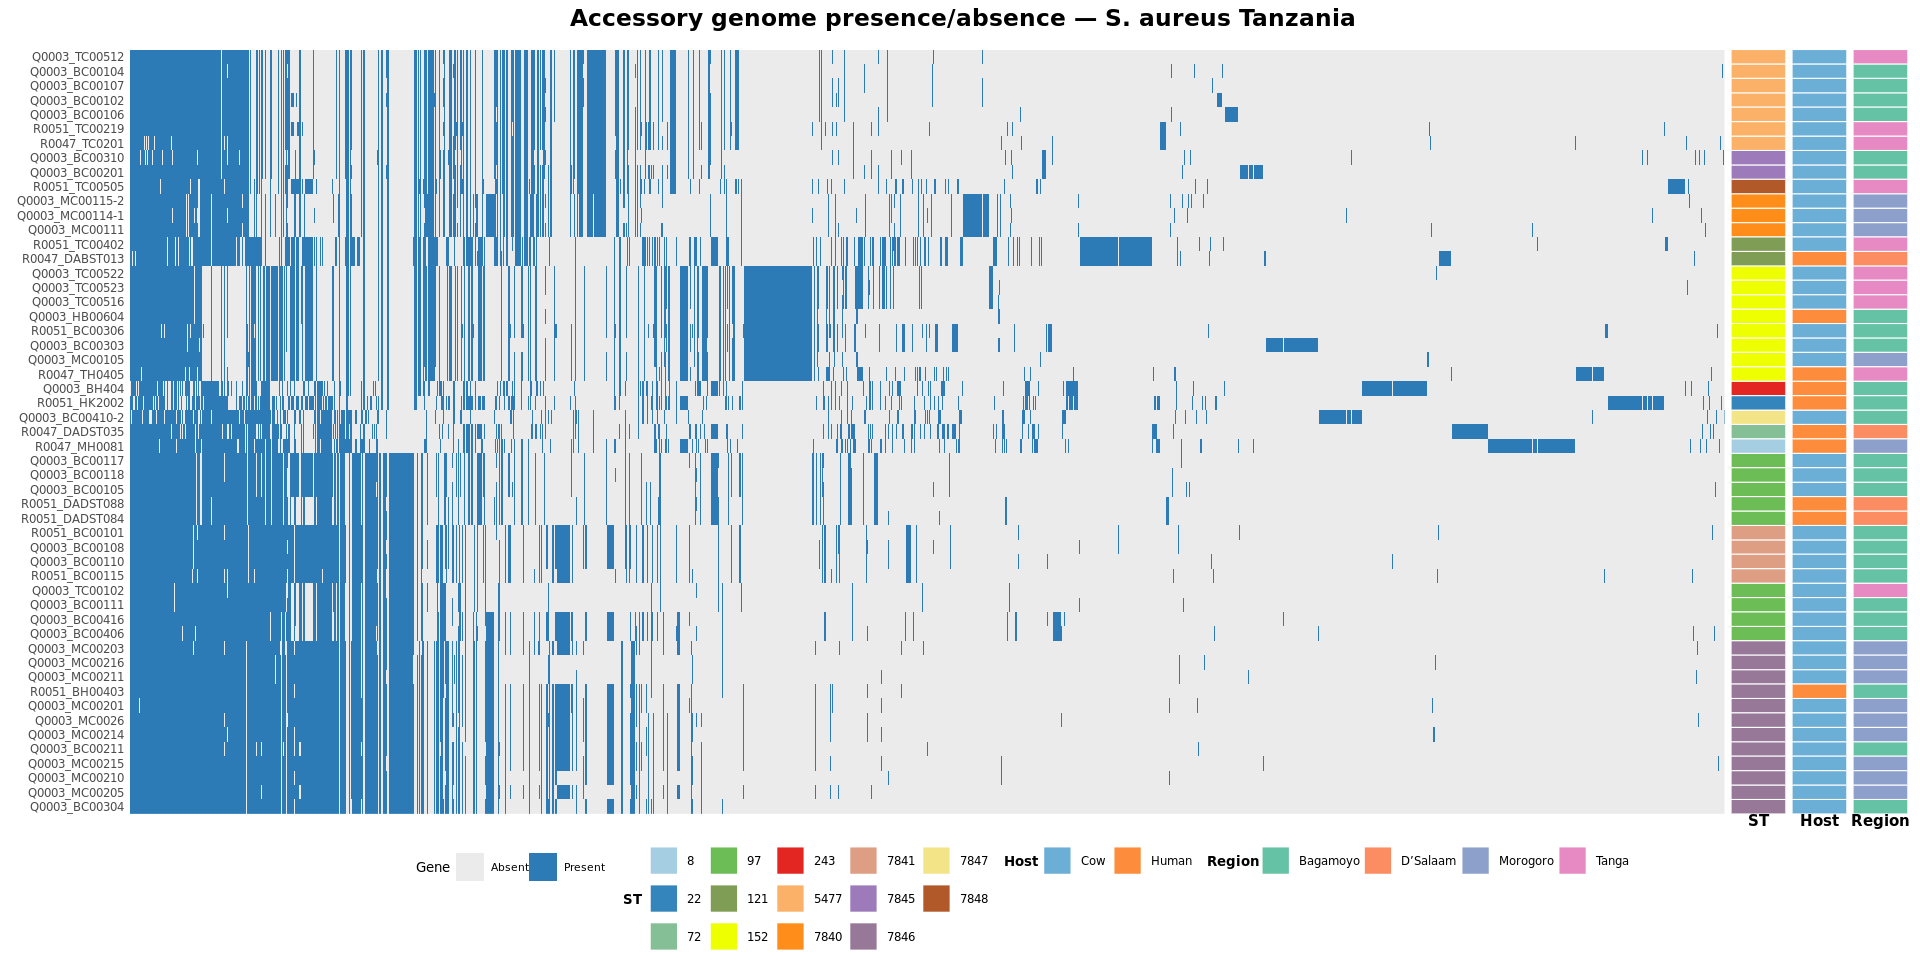

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 8)
library(patchwork)
library(tidyr)
library(dplyr)

# ── load ──────────────────────────────────────────────────────────────────────
gpa <- read.delim(file.path(pangenome_dir, "gene_presence_absence.Rtab"),
                  row.names = 1, check.names = FALSE)

# ── match sample order to tree ────────────────────────────────────────────────
samples_in_order <- tip_order[tip_order %in% colnames(gpa)]
gpa_ordered      <- gpa[, samples_in_order]

# ── keep only accessory genes ─────────────────────────────────────────────────
freq          <- rowSums(gpa_ordered) / ncol(gpa_ordered)
gpa_accessory <- gpa_ordered[freq > 0 & freq < 1, ]   # exclude core (=1) and absent (=0)

cat("Accessory genes:", nrow(gpa_accessory), "\n")

# ── sort genes by frequency (core-like → rare, left → right) ─────────────────
gene_freq  <- rowSums(gpa_accessory)
gpa_sorted <- gpa_accessory[order(gene_freq, decreasing = TRUE), ]

# ── long format ───────────────────────────────────────────────────────────────
gpa_long <- gpa_sorted %>%
  tibble::rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "sample", values_to = "present") %>%
  mutate(
    sample  = factor(sample, levels = samples_in_order),
    gene    = factor(gene,   levels = rownames(gpa_sorted)),
    present = factor(present)
  )

# ── heatmap ───────────────────────────────────────────────────────────────────
p_heatmap <- ggplot(gpa_long, aes(x = gene, y = sample, fill = present)) +
  geom_tile(color = NA) +
  scale_fill_manual(values = c("0" = "grey92", "1" = "#05497d"),
                    labels = c("Absent", "Present"), name = "Gene") +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  theme_minimal(base_size = 8) +
  theme(
    axis.text.x     = element_blank(),
    axis.text.y     = element_text(size = 7),
    axis.ticks      = element_blank(),
    axis.title      = element_blank(),
    panel.grid      = element_blank(),
    legend.position = "bottom",
    plot.margin     = margin(5.5, 2, 0, 5.5)
  )

# ── annotation strips ─────────────────────────────────────────────────────────
annot_ordered <- meta %>%
  filter(sample %in% samples_in_order) %>%
  mutate(label = factor(sample, levels = samples_in_order))

annot_theme <- theme_void() +
  theme(
    axis.title.x    = element_text(size = 9, angle = 0, vjust = 1,
                                   hjust = 0.5, face = "bold"),
    legend.position = "bottom",
    legend.text     = element_text(size = 7),
    legend.title    = element_text(size = 8, face = "bold"),
    plot.margin     = margin(0, 2, 0, 2)
  )

p_st <- ggplot(annot_ordered, aes(y = label, x = 1, fill = factor(ST))) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = st_colours, name = "ST") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "ST") + annot_theme

p_host <- ggplot(annot_ordered, aes(y = label, x = 1, fill = host)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = host_colours, name = "Host") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Host") + annot_theme

p_region <- ggplot(annot_ordered, aes(y = label, x = 1, fill = region)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = region_colours, name = "Region") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Region") + annot_theme

# ── combine ───────────────────────────────────────────────────────────────────
(p_heatmap + p_st + p_host + p_region +
  plot_layout(widths = c(0.88, 0.03, 0.03, 0.03),
              guides = "collect") &
  theme(legend.position = "bottom")) +
  plot_annotation(
    title = "Accessory genome presence/absence — S. aureus Tanzania",
    theme = theme(plot.title = element_text(size = 14, face = "bold", hjust = 0.5))
  )

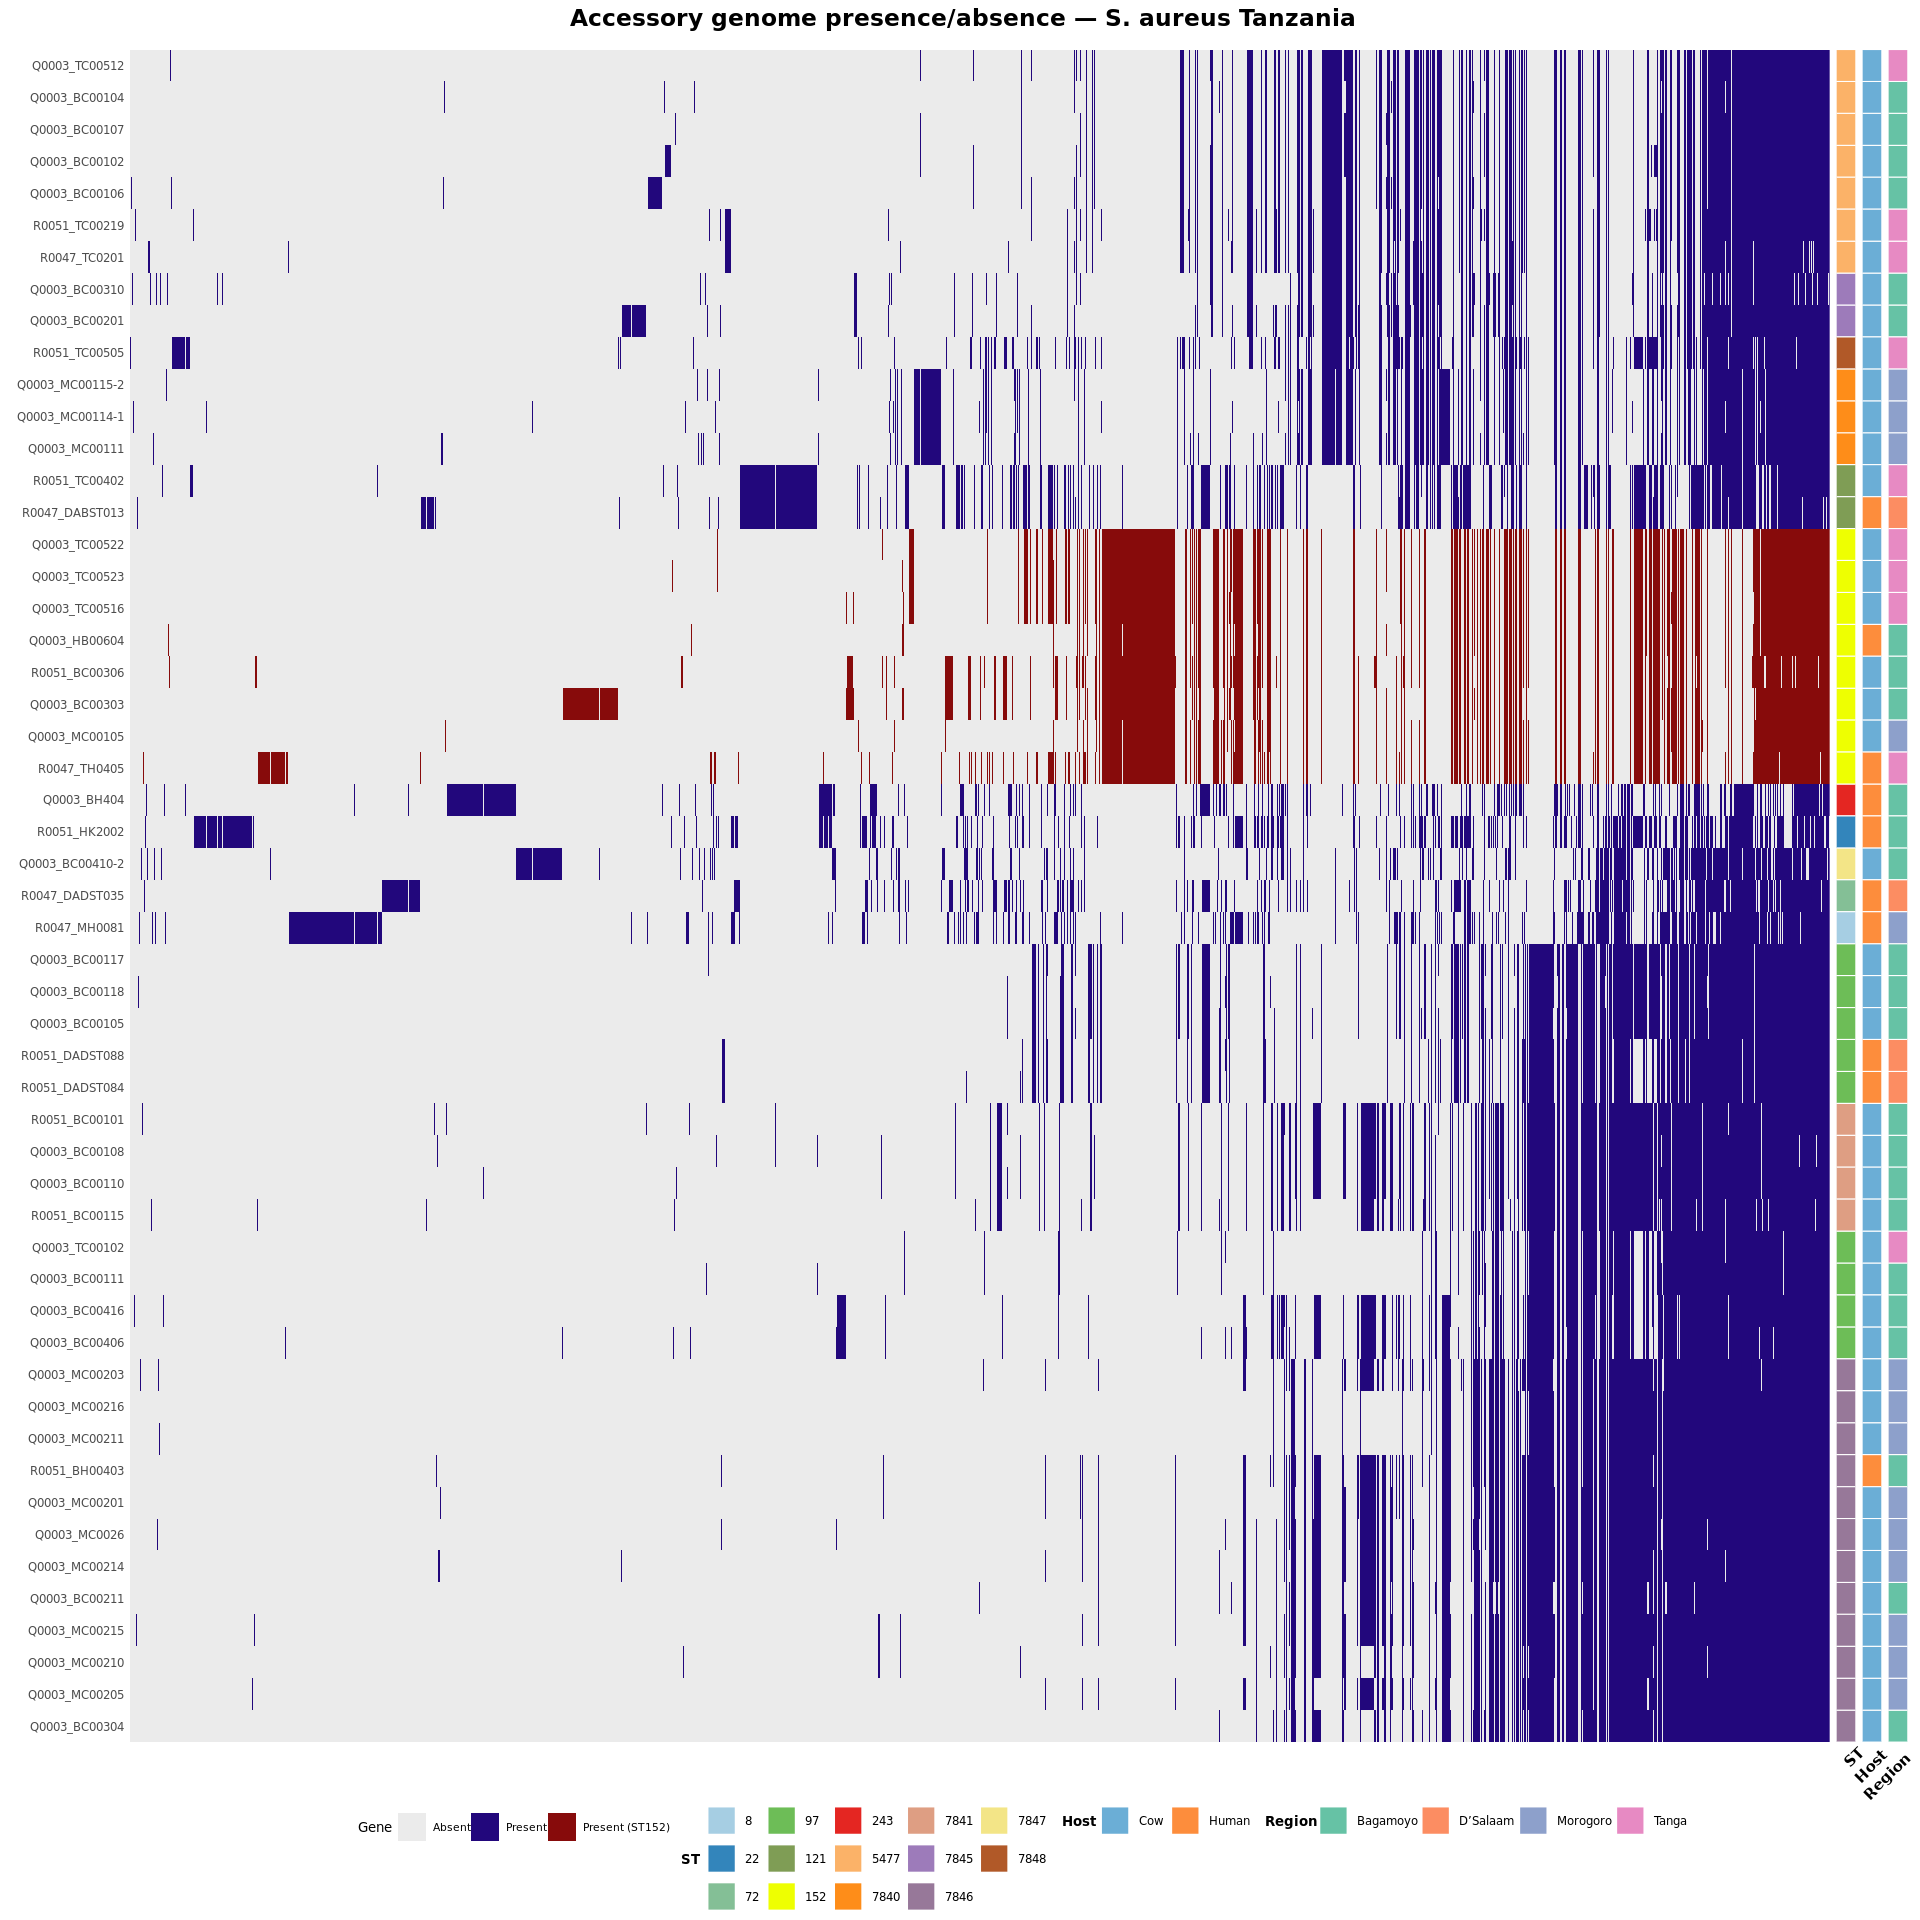

In [40]:
options(repr.plot.width = 16, repr.plot.height = 16)

# ── load ──────────────────────────────────────────────────────────────────────
gpa <- read.delim(file.path(pangenome_dir, "gene_presence_absence.Rtab"),
                  row.names = 1, check.names = FALSE)

# ── match sample order to tree ────────────────────────────────────────────────
samples_in_order <- tip_order[tip_order %in% colnames(gpa)]
gpa_ordered      <- gpa[, samples_in_order]

# ── keep only accessory genes ─────────────────────────────────────────────────
freq          <- rowSums(gpa_ordered) / ncol(gpa_ordered)
gpa_accessory <- gpa_ordered[freq > 0 & freq < 1, ]

# ── sort genes by frequency ───────────────────────────────────────────────────
gene_freq  <- rowSums(gpa_accessory)
gpa_sorted <- gpa_accessory[order(gene_freq, decreasing = TRUE), ]

# ── long format joined with ST info ───────────────────────────────────────────
st_lookup <- meta %>% select(sample, ST)

gpa_long <- gpa_sorted %>%
  tibble::rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "sample", values_to = "present") %>%
  left_join(st_lookup, by = "sample") %>%
  mutate(
    sample   = factor(sample, levels = samples_in_order),
    gene     = factor(gene,   levels = rownames(gpa_sorted)),
    present  = as.integer(as.character(present)),
    # tile colour: yellow if ST152+present, blue if other+present, grey if absent
    fill_col = case_when(
      present == 1 & ST == "152" ~ "ST152",
      present == 1               ~ "Present",
      TRUE                       ~ "Absent"
    )
  )

# ── heatmap ───────────────────────────────────────────────────────────────────
p_heatmap <- ggplot(gpa_long, aes(x = gene, y = sample, fill = fill_col)) +
  geom_tile(color = NA) +
  scale_fill_manual(
    values = c("Absent" = "grey92", "Present" = "#22077c", "ST152" = "#870b0b"),
    labels = c("Absent", "Present", "Present (ST152)"),
    name   = "Gene"
  ) +
  scale_x_discrete(expand = c(0, 0), limits = rev) + 
  scale_y_discrete(expand = c(0, 0), limits = rev) +

  theme_minimal(base_size = 8) +
  theme(
    axis.text.x     = element_blank(),
    axis.text.y     = element_text(size = 7),
    axis.ticks      = element_blank(),
    axis.title      = element_blank(),
    panel.grid      = element_blank(),
    legend.position = "bottom",
    plot.margin     = margin(5.5, 2, 0, 5.5)
  )

# ── annotation strips ─────────────────────────────────────────────────────────
annot_ordered <- meta %>%
  filter(sample %in% samples_in_order) %>%
  mutate(label = factor(sample, levels = samples_in_order))

annot_theme <- theme_void() +
  theme(
    axis.title.x    = element_text(size = 9, angle = 45, vjust = 1,
                                   hjust = 1.2, face = "bold"),
    legend.position = "bottom",
    legend.text     = element_text(size = 7),
    legend.title    = element_text(size = 8, face = "bold"),
    plot.margin     = margin(0, 2, 0, 2)
  )

p_st <- ggplot(annot_ordered, aes(y = label, x = 1, fill = factor(ST))) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = st_colours, name = "ST") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "ST") + annot_theme

p_host <- ggplot(annot_ordered, aes(y = label, x = 1, fill = host)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = host_colours, name = "Host") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Host") + annot_theme

p_region <- ggplot(annot_ordered, aes(y = label, x = 1, fill = region)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = region_colours, name = "Region") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Region") + annot_theme

# ── combine ───────────────────────────────────────────────────────────────────
(p_heatmap + p_st + p_host + p_region +
  plot_layout(widths = c(0.88, 0.01, 0.01, 0.01),
              guides = "collect") &
  theme(legend.position = "bottom")) +
  plot_annotation(
    title = "Accessory genome presence/absence — S. aureus Tanzania",
    theme = theme(plot.title = element_text(size = 14, face = "bold", hjust = 0.5))
  )

### ALL DATA - PANGENOME

In [ ]:
tree_all <- read.tree()

In [62]:
# prepare metadata

meta_our <- meta

meta_pub_unfiltered <- read_tsv("../../results_for_analysis/metadata/africa_target_sts_with_genomes.tsv")
qcpassed_sub <- read_tsv("../../results_for_analysis/metadata/sample_list_augm_postQC.txt", col_names = FALSE)
#head(meta_pub_unfiltered)
#head(qcpassed_sub)

qcpassed_sub <- qcpassed_sub$X1 |>
  str_extract("id(\\d+)") |>
  str_remove("^id")

meta_pub <- meta_pub_unfiltered |>
    filter(id %in% qcpassed_sub) |>
    select(id, country, ST = `ST (MLST)`, ) |>
    mutate(source = "MLSTPUB")

meta_our <- meta_our |>
    mutate(source = "DTU food", country = "Tanzania") |>
    select(id = sample, source, country, ST)


#meta_pub
#meta_our

meta_all <- rbind(meta_our, meta_pub)
#meta_all

#write_tsv(meta_all, "../../results_for_analysis/metadata/joined_filtered.tsv")

Rows: 130 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (8): isolate, country, continent, region, sex, disease, source_category...
dbl (10): id, year, arcC, aroE, glpF, gmk, pta, tpi, yqiL, ST (MLST)

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 112 Columns: 1
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): X1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [65]:
meta2

id,source,country,ST
<chr>,<chr>,<chr>,<fct>
Q0003_BC00102,DTU food,Tanzania,5477
Q0003_BC00104,DTU food,Tanzania,5477
Q0003_BC00105,DTU food,Tanzania,97
Q0003_BC00106,DTU food,Tanzania,5477
Q0003_BC00107,DTU food,Tanzania,5477
Q0003_BC00108,DTU food,Tanzania,7841
Q0003_BC00110,DTU food,Tanzania,7841
Q0003_BC00111,DTU food,Tanzania,97
Q0003_BC00117,DTU food,Tanzania,97


In [66]:
tree2$tip.label

[1] "ST152_id46078_ACJ4246"        "ST152_id46082_ACL2618"       
  [3] "ST152_id46073_ABE4195"        "ST152_id46120_STAPH46-B"     
  [5] "ST152_id46059_AAF0093"        "ST152_id46110_SA43"          
  [7] "ST152_id46058_AAE5707"        "ST152_id46032_237"           
  [9] "ST152_id46064_AAG0106"        "ST152_id46112_SA-HVS"        
 [11] "ST152_id37093_st152i_ep2017"  "ST152_id37105_st152_wp2017"  
 [13] "Q0003_MC00105"                "ST152_id37109_st152ii_ep2017"
 [15] "Q0003_HB00604"                "Q0003_TC00516"               
 [17] "Q0003_TC00522"                "Q0003_TC00523"               
 [19] "Q0003_BC00303"                "R0051_BC00306"               
 [21] "ST152_id46095_ECJ"            "ST152_id46109_SA38"          
 [23] "ST152_id37087_st152_kp2016"   "ST152_id37092_st152i_np2017" 
 [25] "ST152_id37104_st152ii_np2017" "Q0003_MC00114-1"             
 [27] "Q0003_MC00111"                "ST7840_id38587_FF22_MC00111" 
 [29] "Q0003_MC00115-2"              "R0051_TC00505"               
 [31] "ST7848_id38592_FF22_TC00505"  "ST5477_id37098_st5477_np2017"
 [33] "ST5477_id37088_st5477_kp2016" "ST5477_id37103_wp2017"       
 [35] "ST5477_id37107_wp2017"        "Q0003_BC00106"               
 [37] "Q0003_BC00102"                "Q0003_BC00104"               
 [39] "Q0003_TC00512"                "Q0003_BC00107"               
 [41] "R0047_TC0201"                 "R0051_TC00219"               
 [43] "ST5477_id37094_st5477_sp2017" "Q0003_BC00201"               
 [45] "ST7845_id38589_FF22_BC00201"  "Q0003_BC00310"               
 [47] "ST121_id24971_ERR505373"      "ST121_id31033_ERR490607"     
 [49] "ST121_id24973_ERR505392"      "ST121_id30879_ERR490626"     
 [51] "ST121_id24328_ERR505363"      "ST121_id30867_ERR490597"     
 [53] "ST121_id46096_KGH0001"        "ST121_id46118_SPHL046"       
 [55] "ST121_id46119_SPHL048"        "R0047_DABST013"              
 [57] "R0051_TC00402"                "ST121_id38040_18SP"          
 [59] "Q0003_BH404"                  "ST22_id7684_ERR017256"       
 [61] "ST22_id7459_ERR017301"        "ST22_id7529_ERR017291"       
 [63] "ST22_id37156_SA82"            "R0051_HK2002"                
 [65] "ST22_id7735_ERR017257"        "Q0003_BC00410-2"             
 [67] "ST7847_id38591_FF22"          "ST72_id46051_94YELLOW"       
 [69] "ST72_id46108_SA299"           "ST72_id46106_SA232"          
 [71] "ST72_id46076_ABS"             "R0047_DADST035"              
 [73] "ST72_id38586_FF22_DADST035"   "ST8_id37152_SA20"            
 [75] "ST8_id24969_ERR505360"        "ST8_id30866_ERR490594"       
 [77] "ST8_id25291_ERR505344"        "ST8_id31020_ERR490578"       
 [79] "ST8_id31027_ERR490592"        "ST8_id24326_ERR505358"       
 [81] "ST8_id24340_ERR505387"        "ST8_id30877_ERR490621"       
 [83] "ST8_id31015_ERR490573"        "ST8_id25290_ERR505339"       
 [85] "ST8_id25293_ERR505357"        "ST8_id31026_ERR490591"       
 [87] "ST8_id38621_AAU9502_S232"     "ST8_id38623_ABP5011_S53"     
 [89] "R0047_MH0081"                 "ST8_id38630_SA32_S33"        
 [91] "ST8_id46085_ACL"              "ST8_id46125_W-357"           
 [93] "R0051_BC00115"                "Q0003_BC00110"               
 [95] "ST7841_id38588_FF22_BC00110"  "Q0003_BC00108"               
 [97] "R0051_BC00101"                "Q0003_BC00111"               
 [99] "Q0003_TC00102"                "Q0003_BC00406"               
[101] "Q0003_BC00416"                "Q0003_MC00211"               
[103] "Q0003_MC00216"                "Q0003_MC00201"               
[105] "R0051_BH00403"                "Q0003_MC00205"               
[107] "ST7846_id38590_FF22_BC00304"  "Q0003_BC00211"               
[109] "Q0003_MC00210"                "Q0003_MC00215"               
[111] "Q0003_BC00304"                "Q0003_MC00214"               
[113] "Q0003_MC0026"                 "Q0003_MC00203"               
[115] "ST97_id37086_st97i_kp2016"    "ST97_id37089_st97ii_kp2016"  
[117] "ST97_id37096_st97_sp2017"     "ST97_id37108_st97_wp

In [69]:
meta2 

id,source,country,ST
<chr>,<chr>,<chr>,<fct>
Q0003_BC00102,DTU food,Tanzania,5477
Q0003_BC00104,DTU food,Tanzania,5477
Q0003_BC00105,DTU food,Tanzania,97
Q0003_BC00106,DTU food,Tanzania,5477
Q0003_BC00107,DTU food,Tanzania,5477
Q0003_BC00108,DTU food,Tanzania,7841
Q0003_BC00110,DTU food,Tanzania,7841
Q0003_BC00111,DTU food,Tanzania,97
Q0003_BC00117,DTU food,Tanzania,97


Warning message in brewer.pal(9, "Set2"):
“n too large, allowed maximum for palette Set2 is 8
Returning the palette you asked for with that many colors
”


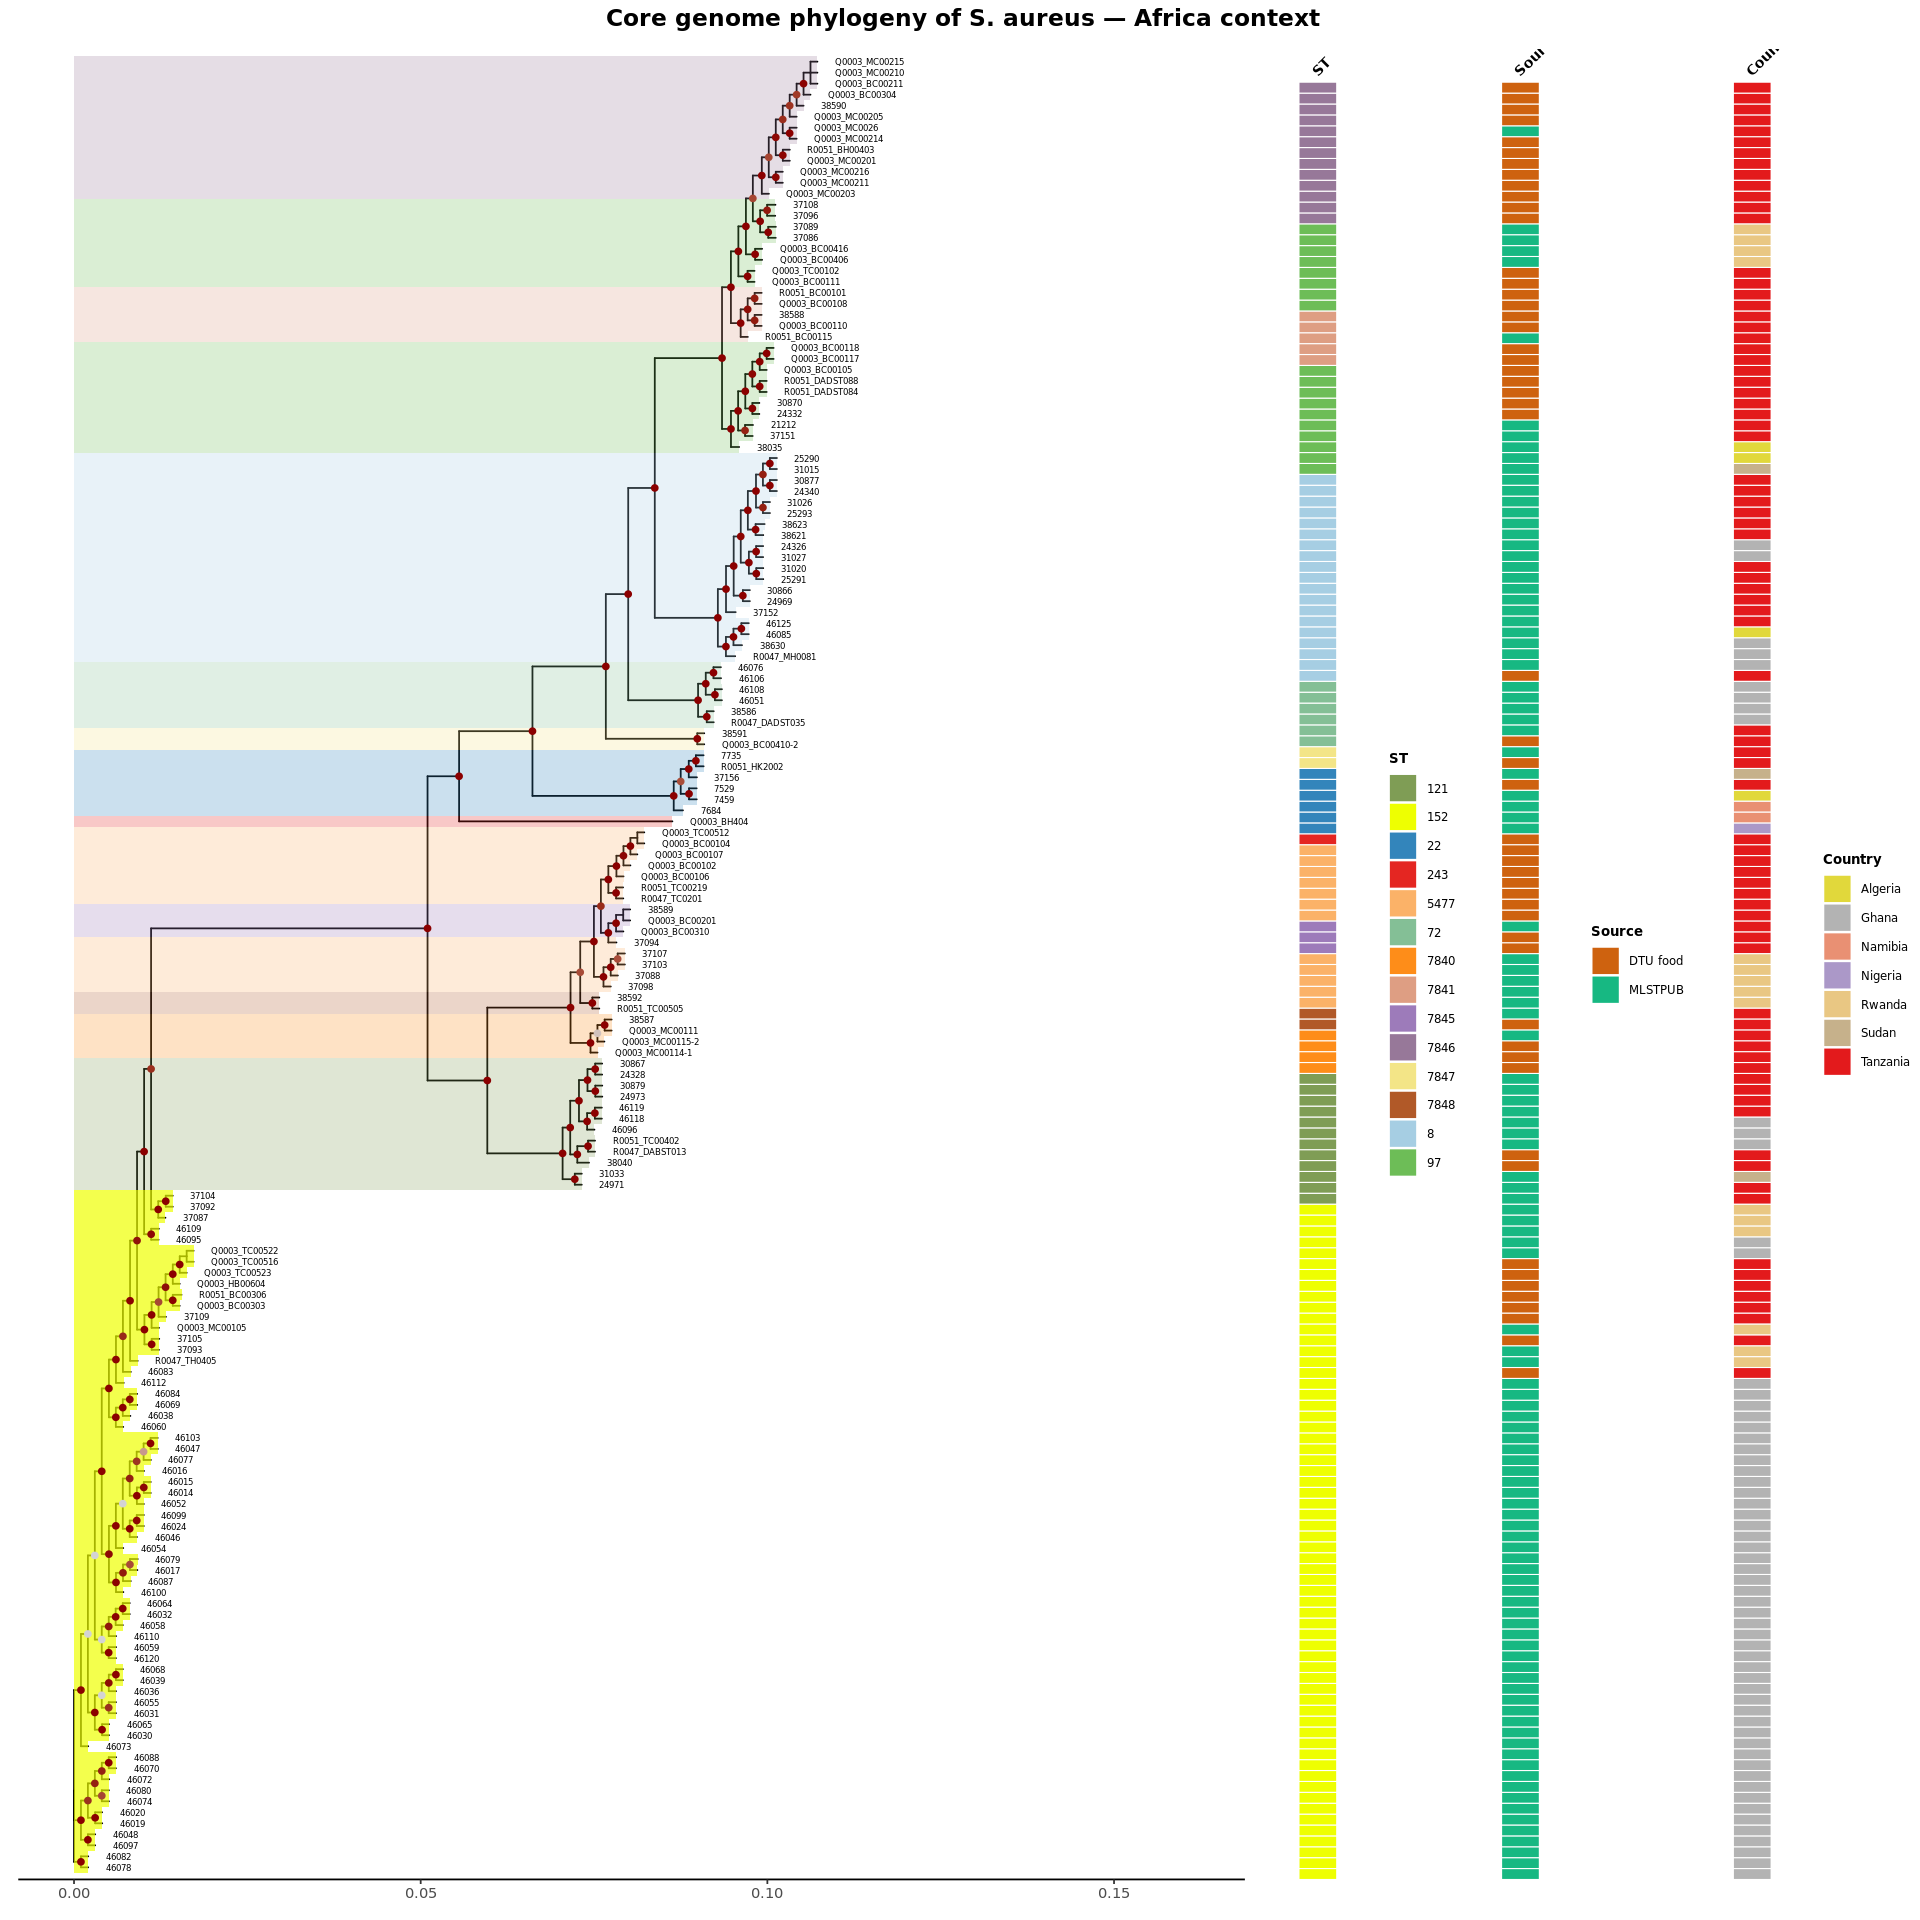

In [73]:
tree2 <- read.tree("../../results_for_analysis/pangenome/all_africa/core_genome_tree.nwk")
meta2 <- meta_all

extract_id <- function(tip) {
  ifelse(
    grepl("^(Q0003|R0047|R0051)", tip),
    tip,                                        # Tanzania: use as-is
    sub(".*_id(\\d+)_.*", "\\1", tip)          # external: extract number after _id
  )
}

all_st <- sort(unique(meta2$ST))
st_pal <- setNames(
  colorRampPalette(brewer.pal(12, "Paired"))(length(all_st)),
  as.character(all_st)
)
st_pal["152"] <- "#eeff01"

country_pal <- setNames(
  colorRampPalette(brewer.pal(9, "Set2"))(length(unique(meta2$country))),
  unique(meta2$country)
)
country_pal["Tanzania"] <- "#E31A1C"   # highlight Tanzania

source_pal <- c("DTU food" = "#ce620f", "MLSTPUB" = "#17b882")




# ── build tree, join metadata by extracted id ─────────────────────────────────
tree2_mod <- tree2
tree2_mod$edge.length <- tree2_mod$edge.length * 3 + 0.001

p_base <- ggtree(tree2_mod)

tip_df <- p_base$data %>%
  filter(isTip) %>%
  mutate(extracted_id = extract_id(label)) %>%
  left_join(meta2, by = c("extracted_id" = "id")) %>%
  mutate(ST = as.character(ST))

# rejoin enriched tip data onto tree
p_base2 <- ggtree(tree2_mod) %<+% tip_df

# ── ST background highlights ──────────────────────────────────────────────────
tip_data2 <- p_base2$data %>%
  filter(isTip) %>%
  mutate(st_alpha = ifelse(!is.na(ST) & ST == "152", 0.7, 0.25))

# ── tree plot ─────────────────────────────────────────────────────────────────
p_tree2 <- p_base2 +
  geom_rect(
    data = tip_data2,
    aes(xmin = 0, xmax = x,
        ymin = y - 0.5, ymax = y + 0.5,
        fill = ST, alpha = st_alpha),
    inherit.aes = FALSE
  ) +
  scale_fill_manual(values = st_pal, name = "ST", na.value = "grey90") +
  scale_alpha_identity() +
  new_scale_color() +
  geom_point2(
    aes(subset = !is.na(suppressWarnings(as.numeric(label))),
        color  = suppressWarnings(as.numeric(label))),
    size = 1.5
  ) +
  scale_color_gradient(low = "lightgrey", high = "darkred",
                       na.value = "grey80", name = "Support") +
  geom_tiplab(aes(label = extracted_id), size = 1.8, offset = 0.002) +
  xlim(0, max(tip_data2$x) * 1.5) +
  theme_tree2() +
  theme(plot.margin     = margin(5.5, 5, 5.5, 5.5),
        legend.position = "none")

# ── annotation panels ─────────────────────────────────────────────────────────
y_min <- min(tip_data2$y) - 0.5
y_max <- max(tip_data2$y) + 0.5

annot_df <- tip_data2 %>%
  select(label, extracted_id, y, ST, source, country) %>%
  arrange(y)

make_strip <- function(data, aes_fill, pal, title, y_min, y_max) {
  ggplot(data, aes(x = 1, y = y, fill = !!sym(aes_fill))) +
    geom_tile(width = 0.8, color = "white", linewidth = 0.3) +
    scale_fill_manual(values = pal, name = title, na.value = "grey90") +
    annotate("text", x = 1, y = y_max + 0.5, label = title,
             angle = 45, hjust = 0, vjust = 0, size = 3, fontface = "bold") +
    scale_x_continuous(breaks = NULL, expand = c(0.5, 0.5)) +
    scale_y_continuous(limits = c(y_min, y_max + 3), expand = c(0, 0)) +
    theme_void() +
    theme(legend.position = "right",
          legend.text     = element_text(size = 7),
          legend.title    = element_text(size = 8, face = "bold"),
          plot.margin     = margin(5.5, 2, 5.5, 2))
}

p_strip_st      <- make_strip(annot_df, "ST",      st_pal,      "ST",      y_min, y_max)
p_strip_source  <- make_strip(annot_df, "source",  source_pal,  "Source",  y_min, y_max)
p_strip_country <- make_strip(annot_df, "country", country_pal, "Country", y_min, y_max)

# ── combine ───────────────────────────────────────────────────────────────────
p_tree2 + p_strip_st + p_strip_source + p_strip_country +
  plot_layout(widths = c(5, 0.5, 0.5, 0.5)) +
  plot_annotation(
    title = "Core genome phylogeny of S. aureus — Africa context",
    theme = theme(plot.title = element_text(size = 14, face = "bold", hjust = 0.5))
  )




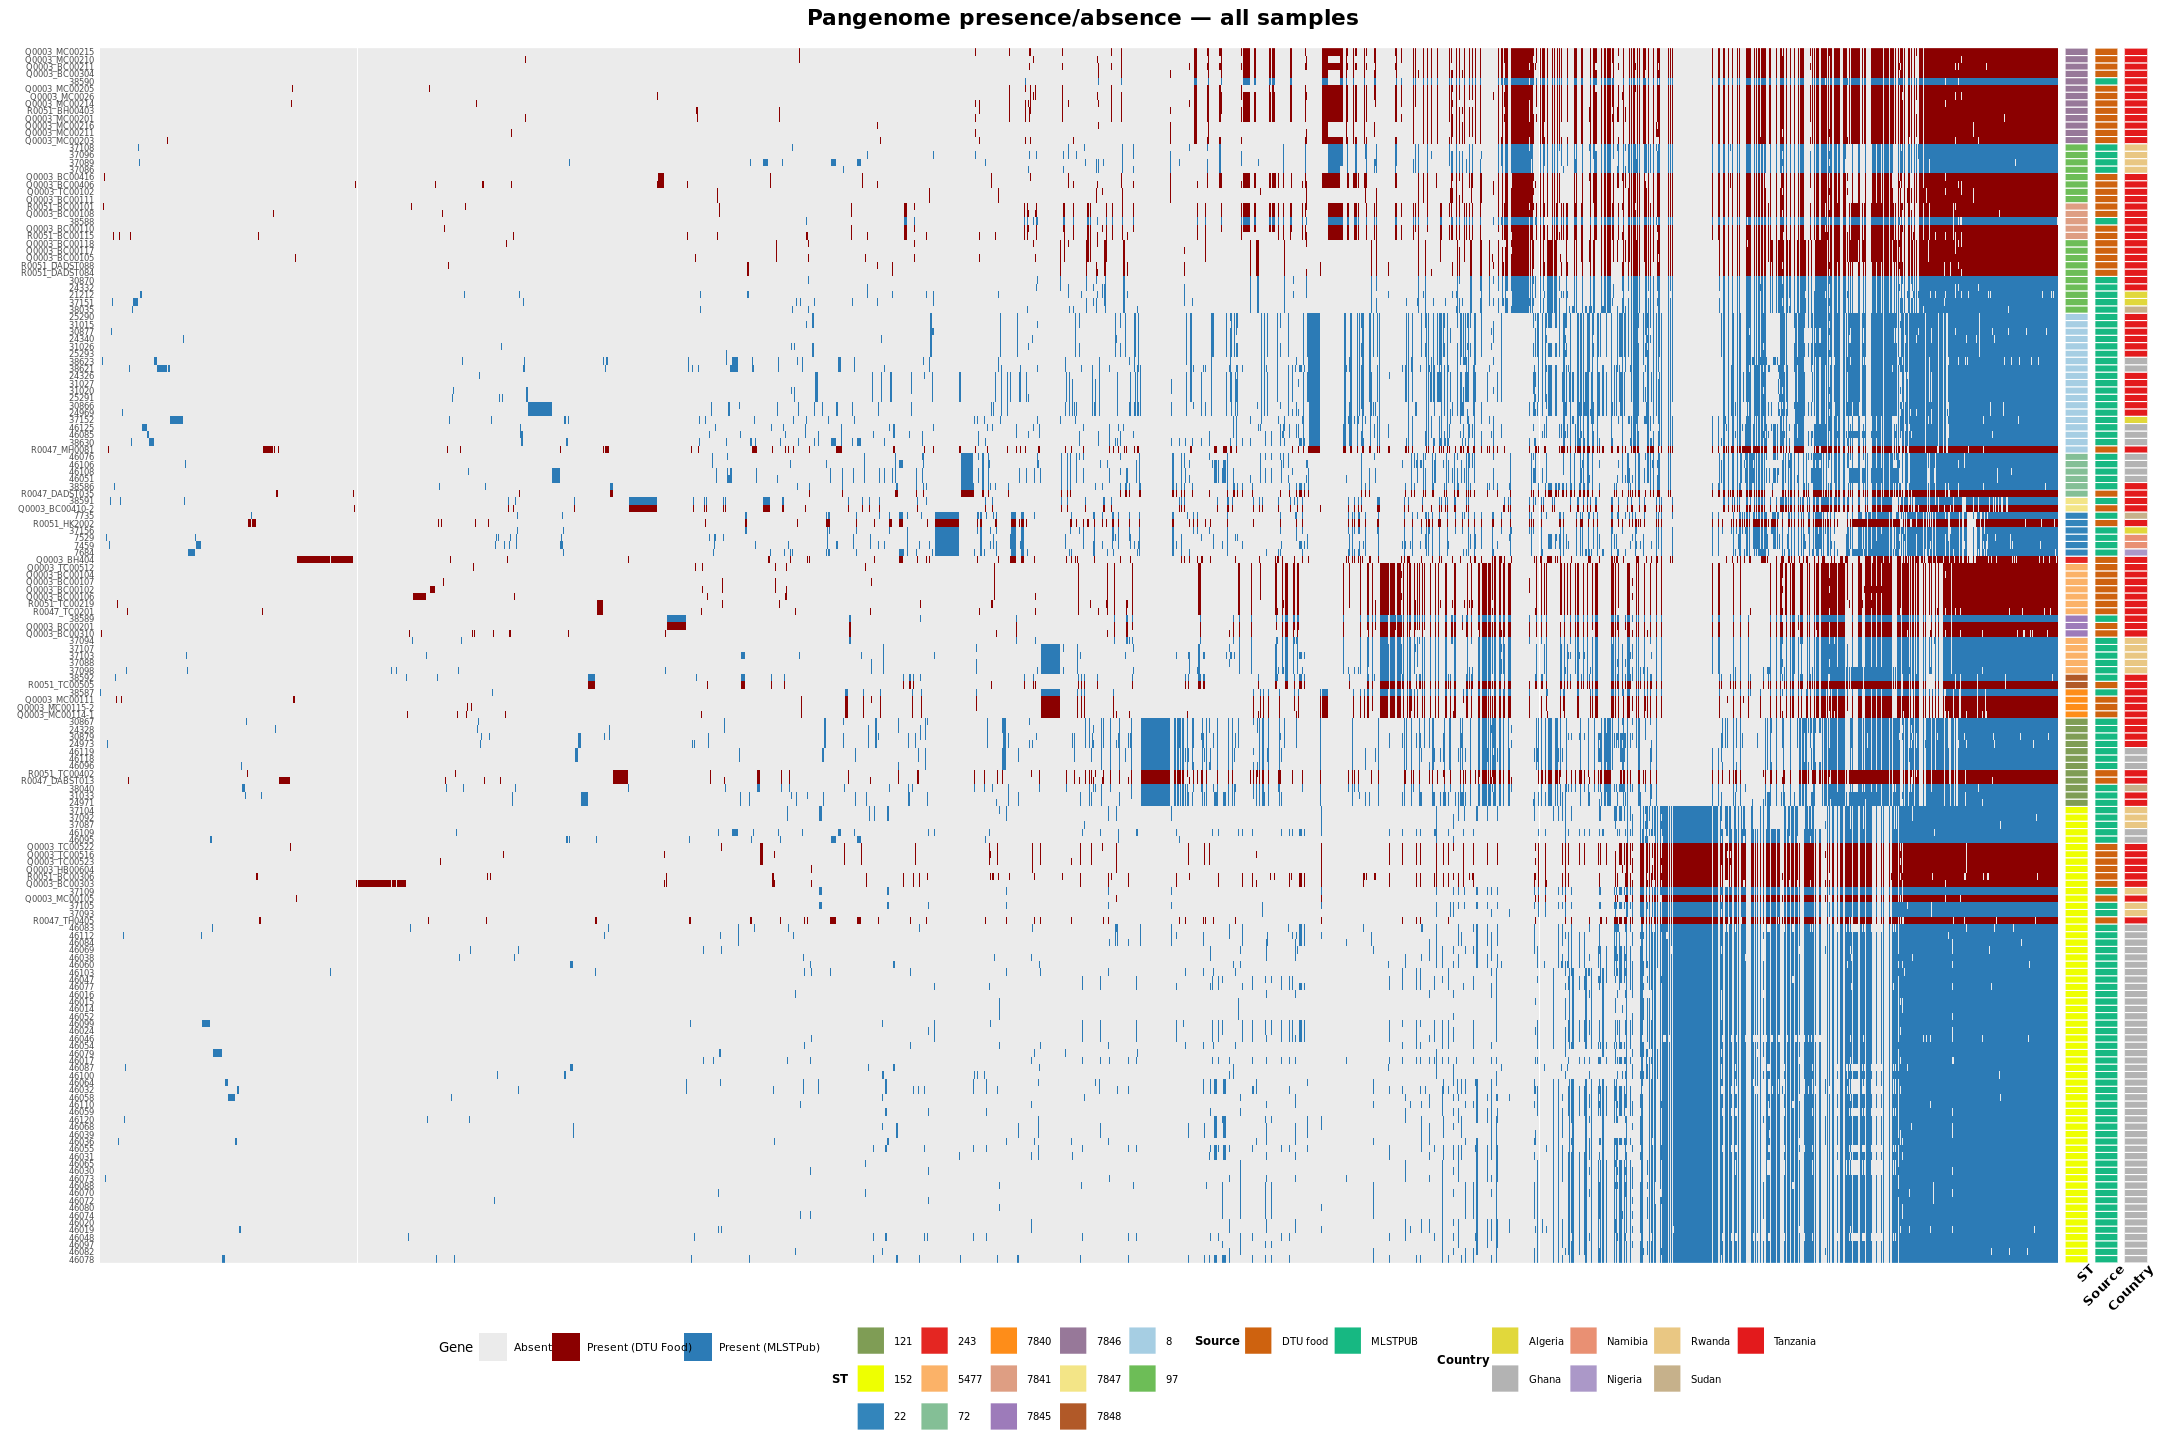

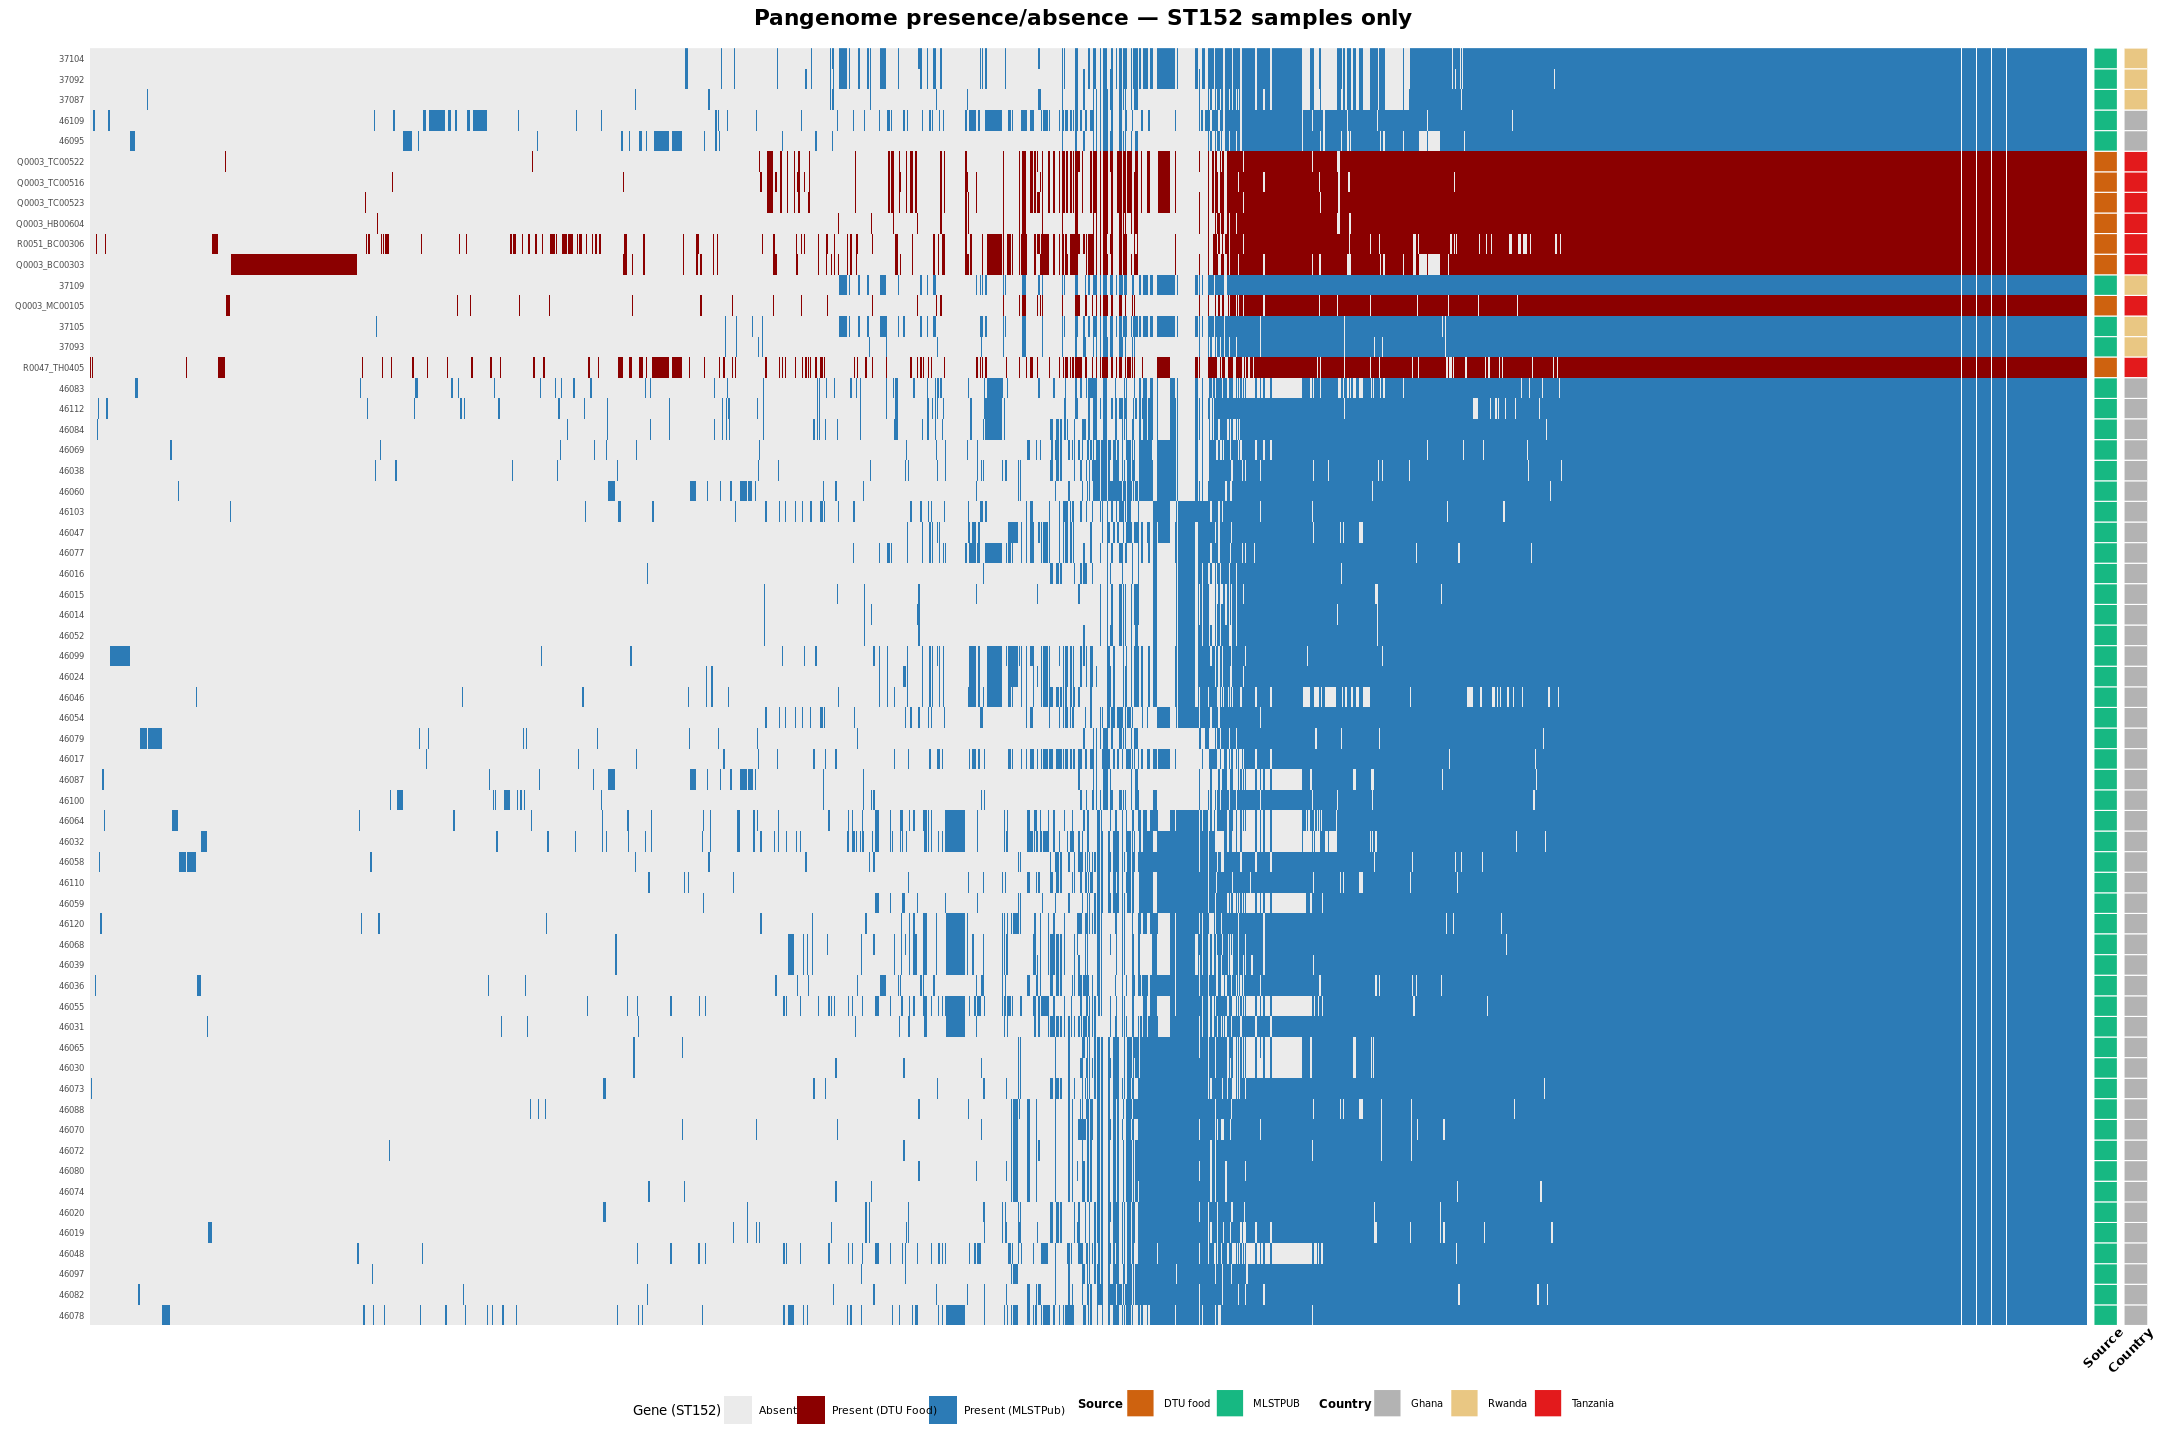

In [82]:
options(repr.plot.width = 18, repr.plot.height = 12)


# ── load new pangenome ────────────────────────────────────────────────────────
gpa2 <- read.delim("../../results_for_analysis/pangenome/all_africa/gene_presence_absence.Rtab",
                   row.names = 1, check.names = FALSE)

# ── get sample order from tree2 ───────────────────────────────────────────────
# tip_df already has extracted_id and y from the tree2 plot
tip_order2 <- tip_df %>%
  filter(isTip) %>%
  arrange(y) %>%
  pull(extracted_id)

extract_col_id <- function(col) {
  ifelse(
    grepl("^(Q0003|R0047|R0051)", col),
    col,                                      # Tanzania: use as-is
    sub(".*_id(\\d+)_.*", "\\1", col)         # external: extract number after _id
  )
}

# rename gpa2 columns to extracted ids
colnames(gpa2) <- extract_col_id(colnames(gpa2))

# keep only samples that appear in gpa2 columns
samples_in_order2 <- tip_order2[tip_order2 %in% colnames(gpa2)]

gpa2_ordered <- gpa2[, samples_in_order2]

# ── sort genes by frequency ───────────────────────────────────────────────────
gene_freq2  <- rowSums(gpa2_ordered)
gpa2_sorted <- gpa2_ordered[order(gene_freq2, decreasing = TRUE), ]

# ── ST152 samples ─────────────────────────────────────────────────────────────
st152_samples <- tip_df %>%
  filter(isTip, !is.na(ST), as.character(ST) == "152") %>%
  pull(extracted_id) %>%
  intersect(colnames(gpa2))

# keep only samples that are in gpa2
st152_in_order <- tip_order2[tip_order2 %in% st152_samples]

gpa2_st152 <- gpa2[, st152_in_order]

# filter to genes present in at least one ST152 sample
st152_gene_mask <- rowSums(gpa2_st152) > 0
gpa2_st152      <- gpa2_st152[st152_gene_mask, ]

# sort by frequency within ST152
st152_freq      <- rowSums(gpa2_st152)
gpa2_st152_sort <- gpa2_st152[order(st152_freq, decreasing = TRUE), ]

# ── full heatmap: accessory only ──────────────────────────────────────────────
freq2         <- rowSums(gpa2_ordered) / ncol(gpa2_ordered)
gpa2_accessory <- gpa2_ordered[freq2 > 0 & freq2 < 1, ]

gene_freq2    <- rowSums(gpa2_accessory)
gpa2_sorted   <- gpa2_accessory[order(gene_freq2, decreasing = TRUE), ]

# ── ST152 heatmap: accessory only ────────────────────────────────────────────
gpa2_st152         <- gpa2_accessory[, st152_in_order]   # subset from accessory, not raw

# keep genes present in at least one ST152 sample
st152_gene_mask    <- rowSums(gpa2_st152) > 0
gpa2_st152         <- gpa2_st152[st152_gene_mask, ]

st152_freq         <- rowSums(gpa2_st152)
gpa2_st152_sort    <- gpa2_st152[order(st152_freq, decreasing = TRUE), ]

# ── helper: make long format ──────────────────────────────────────────────────
make_long <- function(mat, sample_levels, meta_df) {
  # get DTU samples
  dtu_samples <- meta_df %>%
    filter(source == "DTU food") %>%
    pull(extracted_id)
  
  mat %>%
    tibble::rownames_to_column("gene") %>%
    pivot_longer(-gene, names_to = "sample", values_to = "present") %>%
    mutate(
      sample   = factor(sample, levels = rev(sample_levels)),
      gene     = factor(gene,   levels = rownames(mat)),
      present  = as.integer(as.character(present)),
      fill_col = case_when(
        present == 1 & sample %in% dtu_samples ~ "DTU",
        present == 1                            ~ "Present",
        TRUE                                    ~ "Absent"
      )
    )
}

gpa2_long       <- make_long(gpa2_sorted,     samples_in_order2, tip_df %>% filter(isTip))
gpa2_st152_long <- make_long(gpa2_st152_sort, st152_in_order,    tip_df %>% filter(isTip))

# ── annotation for full heatmap ───────────────────────────────────────────────
annot2 <- tip_df %>%
  filter(isTip, extracted_id %in% samples_in_order2) %>%
  select(extracted_id, ST, source, country) %>%
  mutate(
    label   = factor(extracted_id, levels = rev(samples_in_order2)),
    ST      = as.character(ST),
    is_tz   = country == "Tanzania"
  )

annot_st152 <- tip_df %>%
  filter(isTip, extracted_id %in% st152_in_order) %>%
  select(extracted_id, ST, source, country) %>%
  mutate(
    label = factor(extracted_id, levels = rev(st152_in_order)),
    ST    = as.character(ST)
  )

# ── shared annotation theme ───────────────────────────────────────────────────
annot_theme2 <- theme_void() +
  theme(
    axis.title.x  = element_text(size = 8, angle = 45, vjust = 1,
                                 hjust = 1, face = "bold"),
    legend.position = "bottom",
    legend.text     = element_text(size = 6),
    legend.title    = element_text(size = 7, face = "bold"),
    plot.margin     = margin(0, 2, 0, 2)
  )

make_annot_strip <- function(df, fill_var, pal, title, sample_levels) {
  ggplot(df, aes(y = label, x = 1, fill = .data[[fill_var]])) +
    geom_tile(color = "white", linewidth = 0.3) +
    scale_fill_manual(values = pal, name = title, na.value = "grey90") +
    scale_y_discrete(expand = c(0, 0), limits = rev(levels(df$label))) +
    scale_x_continuous(expand = c(0, 0)) +
    labs(x = title) +
    annot_theme2
}

# ── heatmap function ──────────────────────────────────────────────────────────
make_heatmap <- function(long_df, fill_label = "Gene") {
  ggplot(long_df, aes(x = gene, y = sample, fill = fill_col)) +
    geom_tile(color = NA) +
    scale_fill_manual(
      values = c("Absent"  = "grey92",
                 "Present" = "#2c7bb6",
                 "DTU"     = "#8B0000"),
      labels = c("Absent", "Present (DTU Food)", "Present (MLSTPub)"),
      name   = fill_label
    ) +
    scale_x_discrete(expand = c(0, 0), limits = rev) +
    scale_y_discrete(expand = c(0, 0), limits = rev) +
    theme_minimal(base_size = 8) +
    theme(
      axis.text.x     = element_blank(),
      axis.text.y     = element_text(size = 5),
      axis.ticks      = element_blank(),
      axis.title      = element_blank(),
      panel.grid      = element_blank(),
      legend.position = "bottom",
      plot.margin     = margin(5.5, 2, 0, 5.5)
    )
}

# ── build full heatmap ────────────────────────────────────────────────────────
p_h2 <- make_heatmap(gpa2_long)

p_st_strip      <- make_annot_strip(annot2, "ST",      st_pal,      "ST",      samples_in_order2)
p_source_strip  <- make_annot_strip(annot2, "source",  source_pal,  "Source",  samples_in_order2)
p_country_strip <- make_annot_strip(annot2, "country", country_pal, "Country", samples_in_order2)

full_heatmap <- (p_h2 + p_st_strip + p_source_strip + p_country_strip +
  plot_layout(widths = c(0.85, 0.01, 0.01, 0.01), guides = "collect") &
  theme(legend.position = "bottom")) +
  plot_annotation(
    title = "Pangenome presence/absence — all samples",
    theme = theme(plot.title = element_text(size = 13, face = "bold", hjust = 0.5))
  )

# ── build ST152-only heatmap ──────────────────────────────────────────────────
p_h2_152 <- make_heatmap(gpa2_st152_long, fill_label = "Gene (ST152)")

p_st_strip_152      <- make_annot_strip(annot_st152, "ST",      st_pal,      "ST",      st152_in_order)
p_source_strip_152  <- make_annot_strip(annot_st152, "source",  source_pal,  "Source",  st152_in_order)
p_country_strip_152 <- make_annot_strip(annot_st152, "country", country_pal, "Country", st152_in_order)

st152_heatmap <- (p_h2_152 + p_source_strip_152 + p_country_strip_152 +
  plot_layout(widths = c(0.85, 0.01, 0.01), guides = "collect") &
  theme(legend.position = "bottom")) +
  plot_annotation(
    title = "Pangenome presence/absence — ST152 samples only",
    theme = theme(plot.title = element_text(size = 13, face = "bold", hjust = 0.5))
  )

# ── display ───────────────────────────────────────────────────────────────────
full_heatmap
st152_heatmap